In [121]:
%matplotlib inline 
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [122]:
df = pd.read_csv('malta_properties.csv',index_col =[0])
df

,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
0,BALZAN,152000.0,apartment,No,No,2015,3,NaN
1,GOZO,185000.0,house,No,No,2015,3,NaN
2,GOZO,293000.0,house,Yes,No,2015,3,NaN
3,GOZO,145000.0,maisonette,No,No,2015,3,NaN
4,MARSASCALA,85000.0,apartment,No,No,2015,2,NaN
...,...,...,...,...,...,...,...,...
103848,SWIEQI,375000.0,maisonette,No,Yes,2022,3,NaN
103849,TARXIEN,310000.0,maisonette,No,No,2022,3,NaN
103850,VALLETTA,575000.0,house,No,No,2022,3,NaN
103851,ŻEBBUĠ,245000.0,apartment,No,No,2022,3,NaN


In [123]:
df.corr()

,PRICE,DATE,BEDROOM,SQM
PRICE,1.000000,0.133406,0.164774,0.397887
DATE,0.133406,1.000000,-0.017129,-0.007491
BEDROOM,0.164774,-0.017129,1.000000,0.147561
SQM,0.397887,-0.007491,0.147561,1.000000


In [124]:
nms = df[df['SQM'].notna()]
nms.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19336 entries, 12 to 103846
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LOCATION          19336 non-null  object 
 1   PRICE             19336 non-null  float64
 2   TYPE_OF_PROPERTY  19336 non-null  object 
 3   POOL              19336 non-null  object 
 4   GARAGE            19336 non-null  object 
 5   DATE              19336 non-null  int64  
 6   BEDROOM           19336 non-null  int64  
 7   SQM               19336 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 1.3+ MB


In [126]:
sliema = nms[nms['LOCATION']=='SLIEMA']
sliema

,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
26,SLIEMA,220000.0,apartment,No,No,2015,3,175.0
381,SLIEMA,330000.0,apartment,No,Yes,2015,3,120.0
382,SLIEMA,220000.0,apartment,No,No,2015,3,175.0
383,SLIEMA,750000.0,house,Yes,No,2015,3,330.0
386,SLIEMA,319000.0,apartment,No,Yes,2015,3,200.0
...,...,...,...,...,...,...,...,...
103625,SLIEMA,875000.0,apartment,No,No,2022,3,200.0
103628,SLIEMA,499000.0,apartment,No,No,2022,3,175.0
103726,SLIEMA,499000.0,apartment,No,No,2022,3,175.0
103827,SLIEMA,350000.0,apartment,No,No,2022,2,115.0


In [127]:
sliema['TYPE_OF_PROPERTY'].value_counts()

apartment     1261
house          326
maisonette      72
villa            1
Name: TYPE_OF_PROPERTY, dtype: int64

In [128]:
pred_df = sliema[(sliema['TYPE_OF_PROPERTY']=='apartment') & (sliema['POOL']=='No') & (sliema['GARAGE']=='No') & (sliema['DATE']==2022)]

In [129]:
pred_df = pred_df.reset_index(drop=True)

In [130]:
pred_df

,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
0,SLIEMA,590000.0,apartment,No,No,2022,4,215.0
1,SLIEMA,320000.0,apartment,No,No,2022,3,135.0
2,SLIEMA,310000.0,apartment,No,No,2022,3,160.0
3,SLIEMA,500000.0,apartment,No,No,2022,3,150.0
4,SLIEMA,550000.0,apartment,No,No,2022,3,75.0
5,SLIEMA,320000.0,apartment,No,No,2022,3,135.0
6,SLIEMA,310000.0,apartment,No,No,2022,3,160.0
7,SLIEMA,1100000.0,apartment,No,No,2022,3,260.0
8,SLIEMA,320000.0,apartment,No,No,2022,3,135.0
9,SLIEMA,1100000.0,apartment,No,No,2022,3,260.0


In [131]:
pred_df.corr()

,PRICE,DATE,BEDROOM,SQM
PRICE,1.000000,NaN,0.167537,0.782216
DATE,NaN,NaN,NaN,NaN
BEDROOM,0.167537,NaN,1.000000,0.259512
SQM,0.782216,NaN,0.259512,1.000000


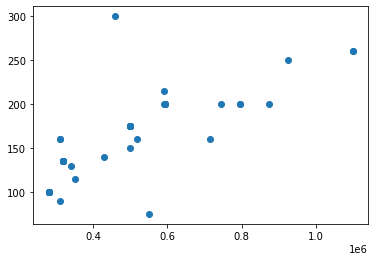

In [150]:
plt.scatter(pred_df['PRICE'],pred_df['SQM'])
plt.savefig('scatter_pred.png',dpi=300, bbox_inches = "tight")
plt.show()

In [133]:
stats.pearsonr(pred_df['PRICE'], pred_df['SQM']) 

(0.7822160576279074, 1.2195842632203556e-11)

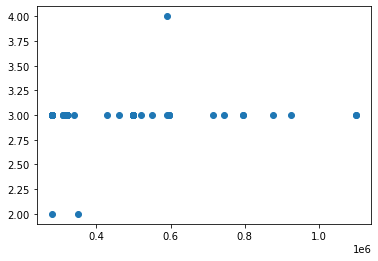

In [151]:
plt.scatter(pred_df['PRICE'],pred_df['BEDROOM'])
plt.savefig('scatter_pred2.png',dpi=300, bbox_inches = "tight")
plt.show()

In [135]:
stats.pearsonr(pred_df['BEDROOM'], pred_df['PRICE']) 

(0.16753662412952885, 0.23994777981868437)

SIMPLE LINEAR REGRESSION to predict the price with sqm

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [137]:
X = pred_df['SQM']
y= pred_df['PRICE']

In [138]:
reg = LinearRegression()

In [139]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [140]:
X_train

14    135.0
46    200.0
18     90.0
48    175.0
42    200.0
15    135.0
31    200.0
30    200.0
16    135.0
43    175.0
20    135.0
50    175.0
8     135.0
13    135.0
25    175.0
5     135.0
17    160.0
37    100.0
40    100.0
1     135.0
12    250.0
38    100.0
24    100.0
6     160.0
23    200.0
36    100.0
21    130.0
19    140.0
9     260.0
39    100.0
49    115.0
3     150.0
0     215.0
47    175.0
44    175.0
Name: SQM, dtype: float64

In [141]:
X_train= X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

In [142]:
X_train

array([[135.],
       [200.],
       [ 90.],
       [175.],
       [200.],
       [135.],
       [200.],
       [200.],
       [135.],
       [175.],
       [135.],
       [175.],
       [135.],
       [135.],
       [175.],
       [135.],
       [160.],
       [100.],
       [100.],
       [135.],
       [250.],
       [100.],
       [100.],
       [160.],
       [200.],
       [100.],
       [130.],
       [140.],
       [260.],
       [100.],
       [115.],
       [150.],
       [215.],
       [175.],
       [175.]])

In [143]:
X_test

array([[175.],
       [135.],
       [300.],
       [200.],
       [160.],
       [200.],
       [175.],
       [100.],
       [100.],
       [ 75.],
       [100.],
       [100.],
       [200.],
       [160.],
       [200.],
       [260.]])

In [144]:
y_test

29     499000.0
11     320000.0
10     460000.0
22     590000.0
2      310000.0
28     595000.0
45     499000.0
32     280000.0
26     280000.0
4      550000.0
33     280000.0
41     280000.0
27     795000.0
35     519000.0
34     595000.0
7     1100000.0
Name: PRICE, dtype: float64

In [145]:
reg.fit(X_train,y_train)
y_pred= reg.predict(X_test)

expected = y_test

In [146]:
y_pred

array([ 559905.11338373,  384033.17029791, 1109504.9355269 ,
        669825.07781236,  493953.13472655,  669825.07781236,
        559905.11338373,  230145.22009782,  230145.22009782,
        120225.25566919,  230145.22009782,  230145.22009782,
        669825.07781236,  493953.13472655,  669825.07781236,
        933632.99244108])

In [147]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(expected, y_pred)
print(mse)

45212910762.33178


In [148]:
reg.score(X_test,y_test)

0.02188691066002635

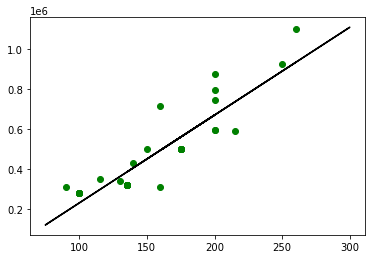

In [152]:
plt.scatter(X_train, y_train,color='g') 
plt.plot(X_test, y_pred,color='k') 
plt.savefig('linear_regression.png',dpi=300, bbox_inches = "tight")
plt.show()